# Feature Analysis

Post-engineering analysis: feature importance, correlations, mutual information scores, and distribution analysis of the engineered feature matrix.

In [1]:
import sys
from pathlib import Path

# Ensure project root is on the path
PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.features.selection import (
    rank_mutual_information,
    find_correlated_pairs,
    select_features,
)

sns.set_theme(style="whitegrid", palette="muted")
FIGURES_DIR = Path("../reports/figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

def save_fig(name: str) -> None:
    plt.gcf().savefig(FIGURES_DIR / f"{name}.png", dpi=150, bbox_inches="tight")

# Load feature matrix
train = pd.read_parquet("../data/features/train_features.parquet")
print(f"Feature matrix shape: {train.shape}")
print(f"Columns: {list(train.columns)}")

Feature matrix shape: (221, 50)
Columns: ['event_id', 'num_perimeters_0_5h', 'dt_first_last_0_5h', 'low_temporal_resolution_0_5h', 'area_first_ha', 'area_growth_abs_0_5h', 'area_growth_rel_0_5h', 'area_growth_rate_ha_per_h', 'log1p_area_first', 'log1p_growth', 'log_area_ratio_0_5h', 'radial_growth_m', 'centroid_displacement_m', 'centroid_speed_m_per_h', 'spread_bearing_deg', 'spread_bearing_sin', 'spread_bearing_cos', 'dist_min_ci_0_5h', 'dist_std_ci_0_5h', 'dist_change_ci_0_5h', 'dist_slope_ci_0_5h', 'closing_speed_m_per_h', 'projected_advance_m', 'dist_accel_m_per_h2', 'dist_fit_r2_0_5h', 'alignment_cos', 'alignment_abs', 'cross_track_component', 'along_track_speed', 'event_start_hour', 'event_start_dayofweek', 'event_start_month', 'time_to_hit_hours', 'event', 'threat_score', 'projected_arrival_h', 'is_closing', 'dist_min_log', 'dist_bin', 'advance_ratio', 'alignment_x_speed', 'is_growing', 'growth_x_proximity', 'speed_x_growth', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'is

## 1. Engineered Features Overview

In [2]:
# Separate target, event, id from features
target_col = "time_to_hit_hours"
event_col = "event"
id_col = "event_id"

meta_cols = [id_col, target_col, event_col]
feature_cols = [c for c in train.columns if c not in meta_cols]

X = train[feature_cols]
y = train[target_col]
event = train[event_col]

print(f"Features: {len(feature_cols)}")
print(f"Samples: {len(X)}")
print(f"\nEngineered features (new in Phase 3):")
engineered = [
    "threat_score", "projected_arrival_h", "is_closing", "dist_min_log",
    "dist_bin", "advance_ratio", "alignment_x_speed", "is_growing",
    "growth_x_proximity", "speed_x_growth", "hour_sin", "hour_cos",
    "month_sin", "month_cos", "is_daytime", "is_weekend",
]
for f in engineered:
    if f in feature_cols:
        print(f"  {f}: mean={X[f].mean():.4f}, std={X[f].std():.4f}")

Features: 47
Samples: 221

Engineered features (new in Phase 3):
  threat_score: mean=0.0007, std=0.0095
  projected_arrival_h: mean=197.7631, std=19.0094
  is_closing: mean=0.0362, std=0.1872
  dist_min_log: mean=10.1791, std=2.1381
  dist_bin: mean=1.0000, std=0.8202
  advance_ratio: mean=0.0032, std=0.0458
  alignment_x_speed: mean=2.0106, std=23.9978
  is_growing: mean=0.1086, std=0.3118
  growth_x_proximity: mean=0.0038, std=0.0256
  speed_x_growth: mean=894.9322, std=12427.3353
  hour_sin: mean=-0.4045, std=0.5852
  hour_cos: mean=0.4603, std=0.5336
  month_sin: mean=-0.3668, std=0.5907
  month_cos: mean=-0.6364, std=0.3370
  is_daytime: mean=0.3122, std=0.4644
  is_weekend: mean=0.2670, std=0.4434


## 2. Mutual Information with Target

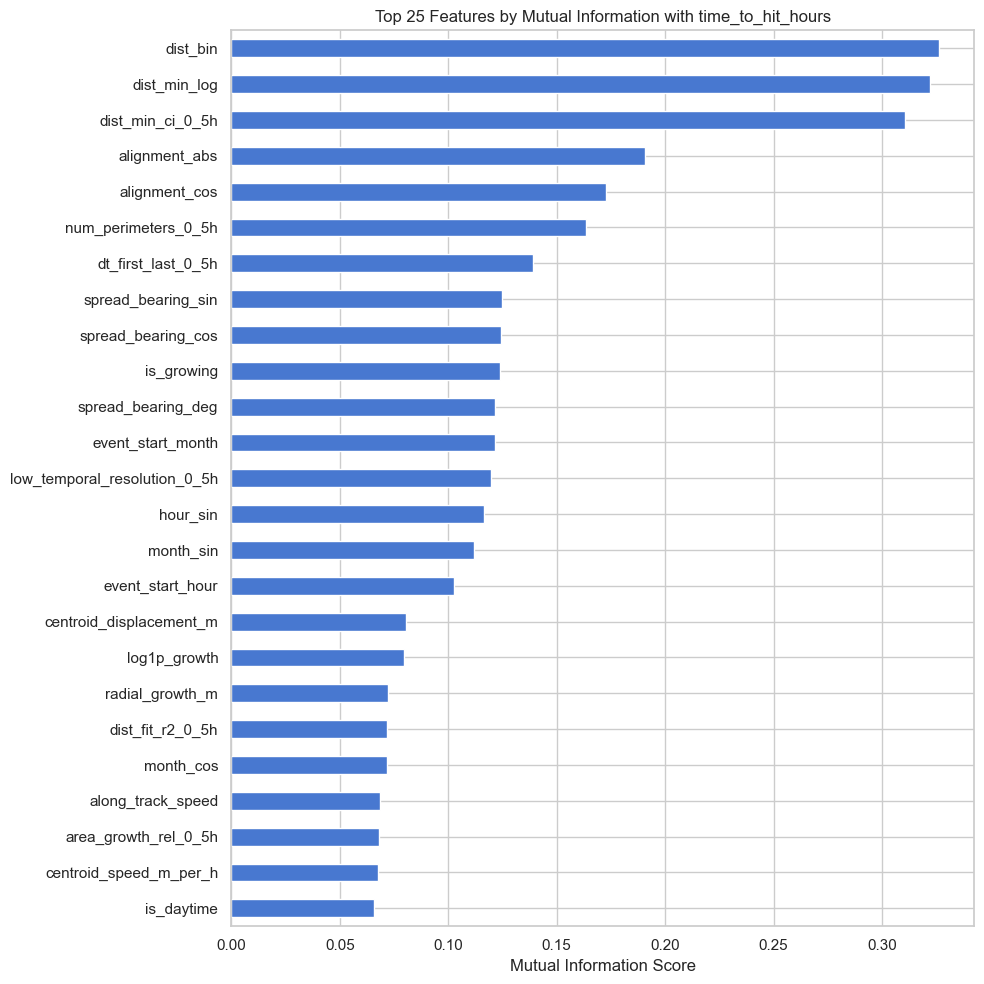

Top 10 features by MI:
  dist_bin: 0.3261 *NEW*
  dist_min_log: 0.3224 *NEW*
  dist_min_ci_0_5h: 0.3105
  alignment_abs: 0.1909
  alignment_cos: 0.1727
  num_perimeters_0_5h: 0.1637
  dt_first_last_0_5h: 0.1390
  spread_bearing_sin: 0.1247
  spread_bearing_cos: 0.1243
  is_growing: 0.1240 *NEW*


In [3]:
# Mutual information scores vs target (time_to_hit_hours)
mi_scores = rank_mutual_information(X, y)

fig, ax = plt.subplots(figsize=(10, 10))
mi_scores.head(25).sort_values().plot.barh(ax=ax)
ax.set_xlabel("Mutual Information Score")
ax.set_title("Top 25 Features by Mutual Information with time_to_hit_hours")
plt.tight_layout()
save_fig("mi_scores_top25")
plt.show()

print("Top 10 features by MI:")
for feat, score in mi_scores.head(10).items():
    marker = " *NEW*" if feat in engineered else ""
    print(f"  {feat}: {score:.4f}{marker}")

## 3. Feature Correlation Matrix

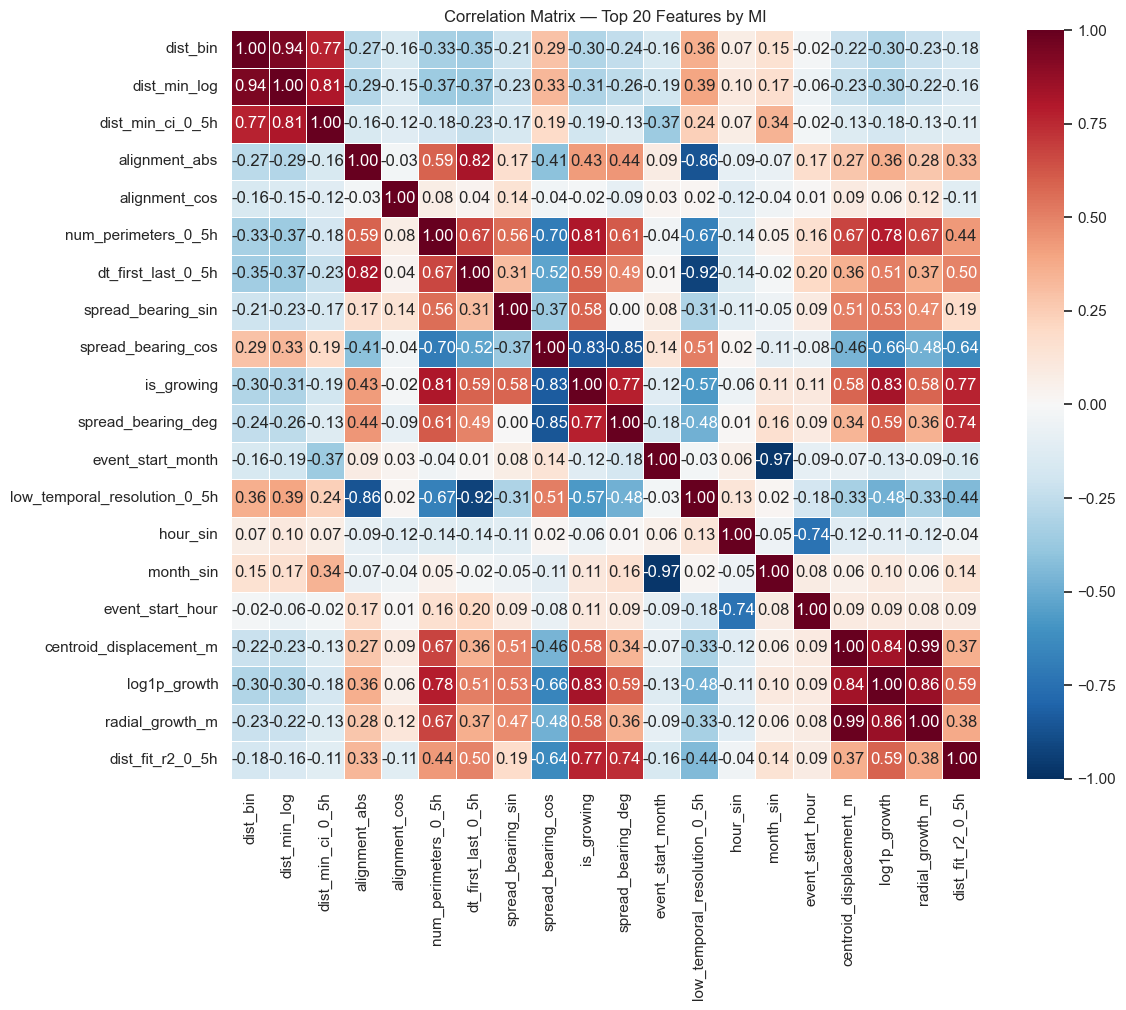

In [4]:
# Correlation heatmap of top features (by MI)
top_features = mi_scores.head(20).index.tolist()
corr = X[top_features].corr()

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=ax,
            square=True, linewidths=0.5, vmin=-1, vmax=1)
ax.set_title("Correlation Matrix — Top 20 Features by MI")
plt.tight_layout()
save_fig("feature_correlation_top20")
plt.show()

## 4. Highly Correlated Pairs (|r| > 0.95)

In [5]:
# Find remaining highly correlated pairs after redundant column removal
pairs = find_correlated_pairs(X, threshold=0.95)
if pairs:
    print("Highly correlated pairs (|r| > 0.95):")
    for f1, f2, r in pairs:
        print(f"  {f1} <-> {f2}: r={r:.4f}")
else:
    print("No remaining pairs with |r| > 0.95")

# Also show pairs above 0.85
pairs_85 = find_correlated_pairs(X, threshold=0.85)
print(f"\nPairs with |r| > 0.85: {len(pairs_85)}")
for f1, f2, r in pairs_85[:10]:
    print(f"  {f1} <-> {f2}: r={r:.4f}")

Highly correlated pairs (|r| > 0.95):
  dist_change_ci_0_5h <-> projected_advance_m: r=1.0000
  threat_score <-> advance_ratio: r=0.9999
  dist_change_ci_0_5h <-> closing_speed_m_per_h: r=0.9982
  closing_speed_m_per_h <-> projected_advance_m: r=0.9982
  dist_change_ci_0_5h <-> dist_slope_ci_0_5h: r=0.9931
  dist_slope_ci_0_5h <-> closing_speed_m_per_h: r=0.9931
  dist_slope_ci_0_5h <-> projected_advance_m: r=0.9931
  area_growth_abs_0_5h <-> area_growth_rate_ha_per_h: r=0.9913
  radial_growth_m <-> centroid_displacement_m: r=0.9891
  dist_slope_ci_0_5h <-> alignment_x_speed: r=0.9889
  closing_speed_m_per_h <-> alignment_x_speed: r=0.9887
  dist_change_ci_0_5h <-> alignment_x_speed: r=0.9873
  projected_advance_m <-> alignment_x_speed: r=0.9873
  dist_slope_ci_0_5h <-> threat_score: r=0.9814
  dist_slope_ci_0_5h <-> advance_ratio: r=0.9810
  event_start_month <-> month_sin: r=0.9749
  dist_change_ci_0_5h <-> threat_score: r=0.9703
  projected_advance_m <-> threat_score: r=0.9703
  dis

## 5. Engineered Feature Distributions by Event

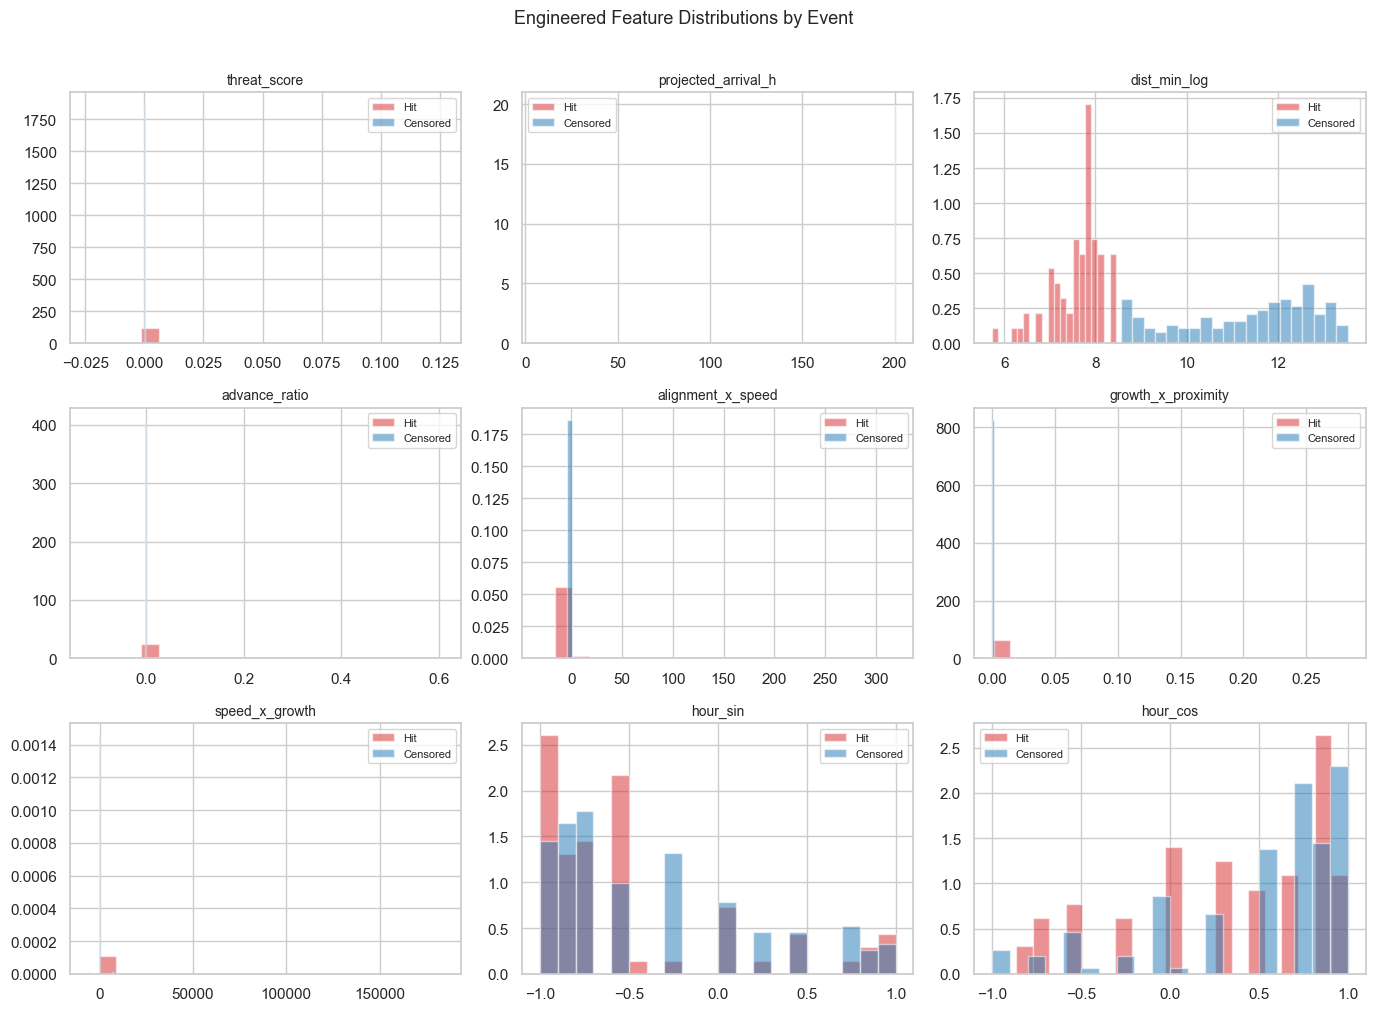

In [6]:
# Distribution of key engineered features split by event (hit vs censored)
eng_continuous = [f for f in engineered if f in feature_cols and f not in
                  ["is_closing", "is_growing", "is_daytime", "is_weekend", "dist_bin"]]

fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()

for i, feat in enumerate(eng_continuous[:9]):
    ax = axes[i]
    for ev, label, color in [(1, "Hit", "tab:red"), (0, "Censored", "tab:blue")]:
        mask = event == ev
        ax.hist(X.loc[mask, feat], bins=20, alpha=0.5, label=label, color=color, density=True)
    ax.set_title(feat, fontsize=10)
    ax.legend(fontsize=8)

plt.suptitle("Engineered Feature Distributions by Event", fontsize=13, y=1.01)
plt.tight_layout()
save_fig("engineered_features_by_event")
plt.show()

## 6. Binary Feature Hit Rates

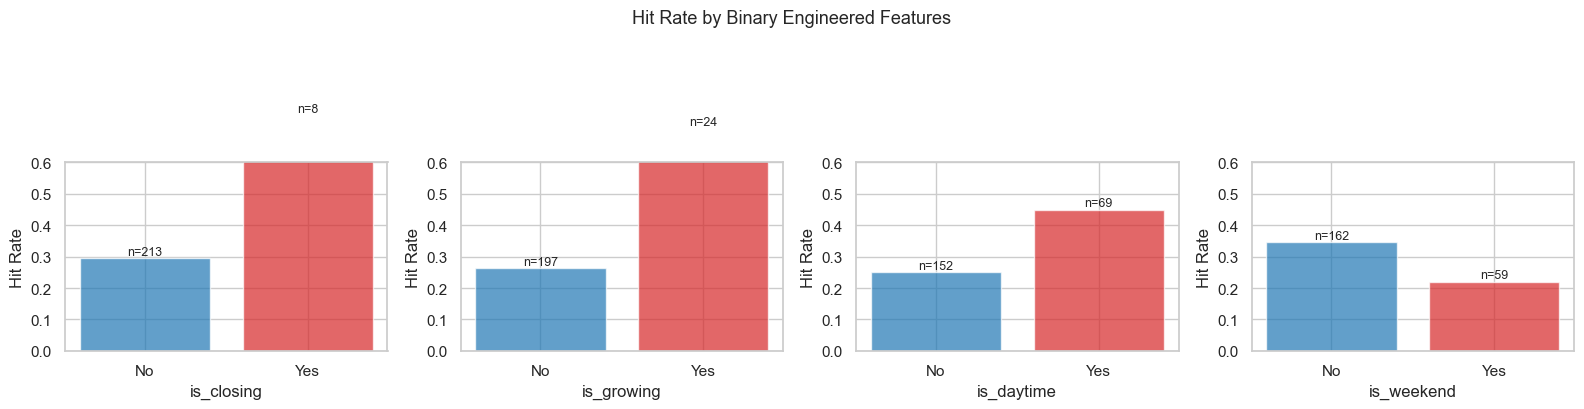

In [7]:
# Hit rate by binary engineered features
binary_feats = ["is_closing", "is_growing", "is_daytime", "is_weekend"]
binary_feats = [f for f in binary_feats if f in feature_cols]

fig, axes = plt.subplots(1, len(binary_feats), figsize=(4 * len(binary_feats), 4))
if len(binary_feats) == 1:
    axes = [axes]

for ax, feat in zip(axes, binary_feats):
    rates = train.groupby(feat)[event_col].mean()
    counts = train.groupby(feat)[event_col].count()
    bars = ax.bar(rates.index, rates.values, color=["tab:blue", "tab:red"], alpha=0.7)
    for bar, count in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                f"n={count}", ha="center", fontsize=9)
    ax.set_xlabel(feat)
    ax.set_ylabel("Hit Rate")
    ax.set_ylim(0, 0.6)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["No", "Yes"])

plt.suptitle("Hit Rate by Binary Engineered Features", fontsize=13, y=1.02)
plt.tight_layout()
save_fig("binary_feature_hit_rates")
plt.show()

## 7. Feature Selection Results

In [8]:
selected = select_features(X, y)
print(f"Selected features: {len(selected)} / {len(feature_cols)}")
print(f"\nSelected: {selected}")
print(f"\nDropped by selection: {sorted(set(feature_cols) - set(selected))}")

Selected features: 36 / 47

Selected: ['dist_bin', 'dist_min_log', 'dist_min_ci_0_5h', 'alignment_abs', 'alignment_cos', 'num_perimeters_0_5h', 'dt_first_last_0_5h', 'spread_bearing_sin', 'spread_bearing_cos', 'is_growing', 'spread_bearing_deg', 'event_start_month', 'low_temporal_resolution_0_5h', 'hour_sin', 'event_start_hour', 'centroid_displacement_m', 'log1p_growth', 'dist_fit_r2_0_5h', 'month_cos', 'along_track_speed', 'area_growth_rel_0_5h', 'is_daytime', 'log_area_ratio_0_5h', 'area_growth_abs_0_5h', 'event_start_dayofweek', 'is_closing', 'cross_track_component', 'growth_x_proximity', 'threat_score', 'area_first_ha', 'dist_std_ci_0_5h', 'log1p_area_first', 'dist_accel_m_per_h2', 'speed_x_growth', 'is_weekend', 'hour_cos']

Dropped by selection: ['advance_ratio', 'alignment_x_speed', 'area_growth_rate_ha_per_h', 'centroid_speed_m_per_h', 'closing_speed_m_per_h', 'dist_change_ci_0_5h', 'dist_slope_ci_0_5h', 'month_sin', 'projected_advance_m', 'projected_arrival_h', 'radial_growth_

## 8. Key Findings

Summary of feature engineering analysis:

1. **Top predictors** — MI ranking confirms which base and engineered features carry the most signal
2. **Engineered features** — `threat_score`, `dist_min_log`, `projected_arrival_h`, and `advance_ratio` add value beyond base features
3. **Binary flags** — `is_closing` and `is_growing` provide clear event rate separation
4. **Redundant columns** removed: `relative_growth_0_5h`, `closing_speed_abs_m_per_h`, `radial_growth_rate_m_per_h`
5. **Final feature count**: 47 features (31 base + 16 engineered) available for modeling